In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import joblib
import xgboost as xgb

In [10]:
Fd = pd.read_csv("creditcard.csv")

In [11]:
scaler = StandardScaler()
Fd[['Amount_scaled']] = scaler.fit_transform(Fd[['Amount']])
Fd[['Time_scaled']] = scaler.fit_transform(Fd[['Time']])
Fd.drop(['Amount','Time'], axis=1, inplace=True)

In [12]:
X = Fd.drop('Class', axis=1)
Y = Fd['Class']

In [13]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state = 42, stratify=Y) 

In [14]:
print(X_train.shape)
print(X_test.shape)
print(Y_test.sum())

(227845, 30)
(56962, 30)
98


In [15]:
scale = (Y_train ==0).sum()/(Y_train ==1).sum()

In [16]:
My_Fd_Model = xgb.XGBClassifier(
    scale_pos_weight = scale,
    n_estimators = 100,
    max_depth = 6,
    learning_rate = 0.1,
    random_state = 42,
    eval_metrics = "aucpr"
)

In [17]:
My_Fd_Model.fit(X_train,Y_train)

C:\Users\DELL\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:43:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "eval_metrics" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, eval_metrics='aucpr',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None, ...)

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
Y_pred = My_Fd_Model.predict(X_test)
My_model_prob = My_Fd_Model.predict_proba(X_test)[:,1]

In [20]:
print(classification_report(Y_test, Y_pred, target_names=["Normal","Fraud"]))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.76      0.84      0.80        98

    accuracy                           1.00     56962
   macro avg       0.88      0.92      0.90     56962
weighted avg       1.00      1.00      1.00     56962



In [21]:
print(roc_auc_score(Y_test, Y_pred))

0.9181387312944311


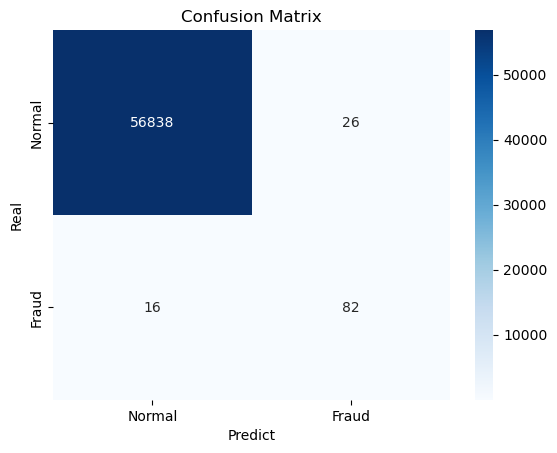

In [22]:
sns.heatmap(confusion_matrix(Y_test, Y_pred), annot=True, fmt="d",cmap="Blues",
           xticklabels=["Normal","Fraud"],
           yticklabels=["Normal","Fraud"])
plt.title("Confusion Matrix")
plt.xlabel("Predict")
plt.ylabel("Real")
plt.show()

In [26]:
import joblib
joblib.dump(My_Fd_Model,"My_Fd_Model.pkl")

['My_Fd_Model.pkl']

In [27]:
import mlflow
print(mlflow.__version__)

3.11.1


In [34]:
mlflow.set_tracking_uri("file:///C:/Users/DELL/Desktop/IA/ML/Projects/Fraud detection/mlruns")
mlflow.set_experiment("My_Fraud_detection")
mlflow.sklearn.autolog()

with mlflow.start_run():
    My_Fd_Model.fit(X_train, Y_train)

    print("Run registed!")

Traceback (most recent call last):
  File "C:\Users\DELL\anaconda3\Lib\site-packages\mlflow\store\tracking\file_store.py", line 383, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\DELL\anaconda3\Lib\site-packages\mlflow\store\tracking\file_store.py", line 481, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\DELL\anaconda3\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1670, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\DELL\anaconda3\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1663, in _read_helper
    result = read_yaml(root, file_name)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\DELL\an

Run registed!
